# Predicting Number of Hops Model Calibration

## This File is Step 3. Loading:
### Bringing in the data to pipeline it into our models and testing the models

## Target (Prediction Task)

**y**: Shortest-path distance (number of hops) between `src` and `dst` artists in the collaboration graph.

To reduce noise and reflect practical search behavior, hop counts are **bucketed** into ordinal classes:

- **1**
- **2**
- **3**
- **4–5**
- **6+**

---

## Feature Set

Features are grouped by **intent**, mirroring how breadth-first search (BFS) expands layers in a graph.

---


In [26]:
feature_groups = {
    # --------------------------------------------------
    # Global embedding geometry (weak prior)
    # --------------------------------------------------
    "geometry": [
        "cos_sim_src_dst",
        "l2_dist_src_dst",
        "dot_src_dst",
        "abs_diff_mean",
        "abs_diff_max",
    ],

    # --------------------------------------------------
    # Popularity priors (weak but stable)
    # --------------------------------------------------
    "popularity": [
        "popularity_src",
        "popularity_dst",
    ],

    # --------------------------------------------------
    # One-hop reachability proxies (CORE SIGNAL)
    # --------------------------------------------------
    "one_hop": [
        # src → dst
        "max_cos_srcnbr_dst",
        "mean_cos_srcnbr_dst",
        "mean_topk_cos_srcnbr_dst",
        "num_src_neighbors",

        # dst → src
        "max_cos_dstnbr_src",
        "mean_cos_dstnbr_src",
        "mean_topk_cos_dstnbr_src",
        "num_dst_neighbors",
    ],

    # --------------------------------------------------
    # Two-hop graph structure (VERY STRONG SIGNAL)
    # --------------------------------------------------
    "two_hop": [
        "shared_neighbors",
        "jaccard_neighbors",
        "adamic_adar",
        "preferential_attachment",
    ],
}


In [27]:
import pandas as pd
import numpy as np

OUTPUT_X_FILE_PATH = '/tmp/embeddings_features.csv'
OUTPUT_Y_FILE_PATH = '/tmp/y_features.csv'


In [28]:
X = pd.read_csv(OUTPUT_X_FILE_PATH)
y = pd.read_csv(OUTPUT_Y_FILE_PATH)
y = y.hops

In [56]:
cnt_y

,hops,proportion
4,0,0.023256
6,1,0.009302
2,2,0.179070
0,3,0.430233
1,4,0.227907
3,5,0.097674
5,6,0.023256
8,7,0.002326
7,8,0.004651
9,9,0.002326


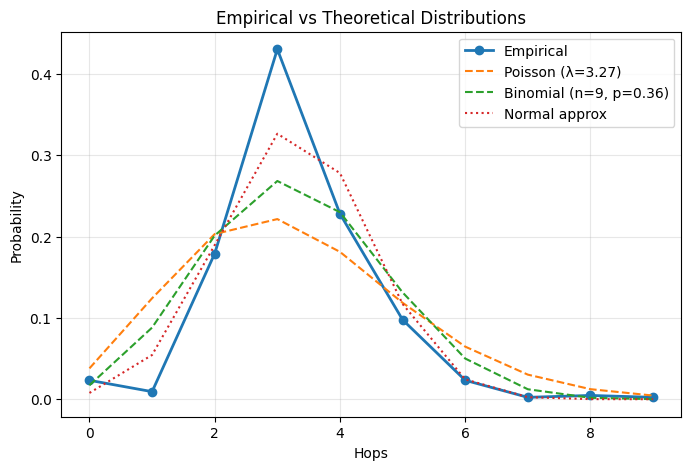

In [59]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson, binom, norm

# -----------------------------
# Empirical distribution
# -----------------------------
cnt = (
    y.value_counts()
     .rename('count')
     .reset_index()
     .rename(columns={'index': 'hops'})
     .sort_values('hops')
)

x = cnt['hops'].values                      # support (1–8)
empirical_p = cnt['count'].values
empirical_p = empirical_p / empirical_p.sum()

# -----------------------------
# Fit distributions
# -----------------------------
mu = y.mean()
sigma = y.std()

# Poisson
poisson_p = poisson.pmf(x, mu=mu)

# Binomial (bounded 1–8)
n = 9
p = mu / n
binom_p = binom.pmf(x, n=n, p=p)

# Normal approximation (normalized)
normal_p = norm.pdf(x, mu, sigma)
normal_p = normal_p / normal_p.sum()

# -----------------------------
# Plot overlay
# -----------------------------
plt.figure(figsize=(8, 5))

plt.plot(x, empirical_p, 'o-', label='Empirical', linewidth=2)
plt.plot(x, poisson_p, '--', label=f'Poisson (λ={mu:.2f})')
plt.plot(x, binom_p, '--', label=f'Binomial (n=9, p={p:.2f})')
plt.plot(x, normal_p, ':', label='Normal approx')

plt.xlabel('Hops')
plt.ylabel('Probability')
plt.title('Empirical vs Theoretical Distributions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()



### Group 1 — Global Geometry (Baseline Model)

**Purpose:**  
*Are these two artists globally close in latent space?*

Derived from Node2Vec embeddings \( e_{src}, e_{dst} \):

- `cos_sim_src_dst`
- `l2_dist_src_dst`
- `dot_src_dst`
- `abs_diff_mean = mean(|e_src − e_dst|)`
- `abs_diff_max = max(|e_src − e_dst|)`

These features define the **embedding-only baseline**.

---


In [4]:
X.shape,y.shape

((430, 22), (430,))

##### Model Selection
- Selecting Variables
- Explanatory

In [5]:
X.num_src_neighbors.value_counts()

num_src_neighbors
2    155
4    104
3     81
1     35
5     28
6     27
Name: count, dtype: int64

In [6]:
pd.set_option('display.max_columns',None)
X.head()

,Unnamed: 0,cos_sim_src_dst,l2_dist_src_dst,dot_src_dst,abs_diff_mean,abs_diff_max,popularity_src,popularity_dst,max_cos_srcnbr_dst,mean_cos_srcnbr_dst,mean_topk_cos_srcnbr_dst,num_src_neighbors,max_cos_dstnbr_src,mean_cos_dstnbr_src,mean_topk_cos_dstnbr_src,num_dst_neighbors,shared_neighbors,jaccard_neighbors,adamic_adar,preferential_attachment,src,dst
0,0,0.797945,0.635696,0.797945,0.091413,0.241038,7.4391,1.9722,0.892812,0.792946,0.853364,4,0.899613,0.898884,0.898884,2,0,0.0,0.0,8,cc2c9c3c-b7bc-4b8b-84d8-4fbd8779e493,47c70105-e0d5-46fe-961e-026651754d77
1,1,0.893522,0.461472,0.893522,0.066746,0.180067,7.4391,7.3830,0.907617,0.814288,0.863111,4,0.905373,0.830477,0.895926,6,0,0.0,0.0,24,cc2c9c3c-b7bc-4b8b-84d8-4fbd8779e493,e0140a67-e4d1-4f13-8a01-364355bee46e
2,2,0.926239,0.384086,0.926239,0.054499,0.177146,7.4391,5.5790,0.950169,0.846246,0.920310,4,0.908046,0.828002,0.828002,3,0,0.0,0.0,12,cc2c9c3c-b7bc-4b8b-84d8-4fbd8779e493,0fed966c-27ce-4866-a122-06d4133d8207
3,3,0.708812,0.763136,0.708812,0.109159,0.381250,7.4391,7.2896,0.799357,0.681668,0.754973,4,0.911175,0.892776,0.892776,3,0,0.0,0.0,12,cc2c9c3c-b7bc-4b8b-84d8-4fbd8779e493,1a425bbd-cca4-4b2c-aeb7-71cb176c828a
4,4,0.891405,0.466036,0.891405,0.070173,0.165187,7.4391,7.7018,0.931339,0.843674,0.910436,4,0.896838,0.750199,0.750199,3,0,0.0,0.0,12,cc2c9c3c-b7bc-4b8b-84d8-4fbd8779e493,9fff2f8a-21e6-47de-a2b8-7f449929d43f


In [29]:
X_explore = X[['cos_sim_src_dst', 'l2_dist_src_dst', 'dot_src_dst',
       'abs_diff_mean', 'abs_diff_max', 'popularity_src', 'popularity_dst',
       'max_cos_srcnbr_dst', 'mean_cos_srcnbr_dst', 'mean_topk_cos_srcnbr_dst',
       'num_src_neighbors', 'max_cos_dstnbr_src', 'mean_cos_dstnbr_src',
       'mean_topk_cos_dstnbr_src', 'num_dst_neighbors']]

In [8]:
import numpy as np
from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

def fit_group(X, y):
    pipe = Pipeline([
        # 1. Impute first
        ("imputer", SimpleImputer(
            strategy="median"   # robust, preserves monotonicity
        )),
        # 2. Scale (important for Elastic Net)
        ("scaler", StandardScaler()),
        # 3. Elastic Net
        ("enet", ElasticNetCV(
            l1_ratio=[0.3, 0.5, 0.7, 0.9, 1.0],
            alphas=np.logspace(-4, 1, 50),
            cv=5,
            max_iter=15000
        ))
    ])

    pipe.fit(X, y)
    return pipe.named_steps["enet"].coef_


In [9]:
X.columns

Index(['Unnamed: 0', 'cos_sim_src_dst', 'l2_dist_src_dst', 'dot_src_dst',
       'abs_diff_mean', 'abs_diff_max', 'popularity_src', 'popularity_dst',
       'max_cos_srcnbr_dst', 'mean_cos_srcnbr_dst', 'mean_topk_cos_srcnbr_dst',
       'num_src_neighbors', 'max_cos_dstnbr_src', 'mean_cos_dstnbr_src',
       'mean_topk_cos_dstnbr_src', 'num_dst_neighbors', 'shared_neighbors',
       'jaccard_neighbors', 'adamic_adar', 'preferential_attachment', 'src',
       'dst'],
      dtype='object')

In [10]:
import numpy as np
import pandas as pd

from sklearn.linear_model import ElasticNetCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.utils import resample
from scipy import stats


def elastic_net_diagnostics(
    X,
    y,
    feature_names,
    n_bootstrap=100,
    random_state=42
):
    rng = np.random.RandomState(random_state)

    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("enet", ElasticNetCV(
            l1_ratio=[0.3, 0.5, 0.7, 0.9, 1.0],
            alphas=np.logspace(-4, 1, 50),
            cv=5,
            max_iter=15000
        ))
    ])

    # ---- Fit on full data ----
    pipe.fit(X, y)
    base_coef = pipe.named_steps["enet"].coef_

    # ---- Bootstrap ----
    boot_coefs = np.zeros((n_bootstrap, X.shape[1]))

    for i in range(n_bootstrap):
        Xb, yb = resample(X, y, random_state=rng.randint(1e9))
        pipe.fit(Xb, yb)
        boot_coefs[i] = pipe.named_steps["enet"].coef_

    # ---- Stability metrics ----
    selection_freq = (boot_coefs != 0).mean(axis=0)

    coef_mean = boot_coefs.mean(axis=0)
    coef_std = boot_coefs.std(axis=0)

    # Sign stability (only when selected)
    sign_stability = np.zeros(X.shape[1])

    for j in range(X.shape[1]):
        nonzero = boot_coefs[:, j] != 0
        if nonzero.any():
            signs = np.sign(boot_coefs[nonzero, j])
            sign_stability[j] = np.abs(signs.mean())
        else:
            sign_stability[j] = np.nan

    # ---- Post-selection OLS (approximate p-values) ----
    pvals = np.full(X.shape[1], np.nan)
    selected_idx = np.where(base_coef != 0)[0]

    if len(selected_idx) > 0:
        X_sel = X[:, selected_idx]
        X_sel = SimpleImputer(strategy="median").fit_transform(X_sel)
        X_sel = StandardScaler().fit_transform(X_sel)

        ols = LinearRegression().fit(X_sel, y)
        y_hat = ols.predict(X_sel)
        resid = y - y_hat

        n, k = X_sel.shape
        sigma2 = np.sum(resid ** 2) / (n - k)
        XtX_inv = np.linalg.inv(X_sel.T @ X_sel)

        se = np.sqrt(np.diag(sigma2 * XtX_inv))
        t_stats = ols.coef_ / se
        pvals_sel = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=n - k))

        pvals[selected_idx] = pvals_sel

    # ---- Assemble table ----
    df = pd.DataFrame({
        "feature": feature_names,
        "coef": base_coef,
        "boot_mean": coef_mean,
        "boot_std": coef_std,
        "selection_freq": selection_freq,
        "sign_stability": sign_stability,
        "p_value_approx": pvals
    })

    return df.sort_values(
        ["selection_freq", "sign_stability"],
        ascending=False
    )


In [11]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [12]:
geom_features = feature_groups["geometry"]

for gr,feat in feature_groups.items():
    df = elastic_net_diagnostics(
        X=X[feat].values,
        y=y.values,
        feature_names=feat,
        n_bootstrap=200
    )
    print(f"========================== {gr} ==========================")
    display(df)


========================== geometry ==========================


,feature,coef,boot_mean,boot_std,selection_freq,sign_stability,p_value_approx
1,l2_dist_src_dst,0.0,0.847351,0.904955,0.680,1.000000,NaN
4,abs_diff_max,0.0,-0.081924,0.162492,0.625,0.360000,NaN
2,dot_src_dst,0.0,0.208875,0.225421,0.580,1.000000,NaN
0,cos_sim_src_dst,0.0,0.144707,0.166521,0.535,1.000000,NaN
3,abs_diff_mean,0.0,-0.379160,0.558881,0.510,0.607843,NaN


========================== popularity ==========================


,feature,coef,boot_mean,boot_std,selection_freq,sign_stability,p_value_approx
1,popularity_dst,-0.182693,-0.181690,0.044572,0.995,1.0,0.001125
0,popularity_src,-0.233610,-0.218401,0.069130,0.990,1.0,0.000033


========================== one_hop ==========================


,feature,coef,boot_mean,boot_std,selection_freq,sign_stability,p_value_approx
3,num_src_neighbors,-0.192881,-0.157058,0.100948,0.940,0.914894,0.000850
6,mean_topk_cos_dstnbr_src,0.277593,0.543912,0.570001,0.910,1.000000,0.003849
2,mean_topk_cos_srcnbr_dst,-0.123317,-0.356394,0.333154,0.835,0.988024,0.082971
7,num_dst_neighbors,0.020630,-0.000596,0.084186,0.780,0.115385,0.545423
4,max_cos_dstnbr_src,-0.151836,-0.176505,0.133217,0.760,1.000000,0.042967
0,max_cos_srcnbr_dst,0.056592,0.150673,0.204773,0.680,0.573529,0.166858
1,mean_cos_srcnbr_dst,0.000000,0.143160,0.222242,0.560,0.696429,NaN
5,mean_cos_dstnbr_src,0.000000,-0.254161,0.525734,0.515,0.242718,NaN


========================== two_hop ==========================


,feature,coef,boot_mean,boot_std,selection_freq,sign_stability,p_value_approx
0,shared_neighbors,-0.084918,-0.079929,0.033100,0.940,1.000000,0.911252
3,preferential_attachment,-0.116691,-0.103947,0.068730,0.900,0.955556,0.048630
1,jaccard_neighbors,-0.030696,-0.026127,0.020413,0.870,1.000000,0.961372
2,adamic_adar,-0.028322,-0.019199,0.019315,0.635,0.968504,0.881455


In [23]:
FINAL_FEATURES = [
    # popularity
    "popularity_src",
    "popularity_dst",

    # one-hop
    "num_src_neighbors",
    "num_dst_neighbors",
    "max_cos_srcnbr_dst",
    "max_cos_dstnbr_src",
    "mean_topk_cos_srcnbr_dst",
    "mean_topk_cos_dstnbr_src",

    # two-hop
    "shared_neighbors",
    "jaccard_neighbors",
    "adamic_adar",
    "preferential_attachment"
]

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


def plot_error_by_hop(y_true, y_pred):
    df = pd.DataFrame({
        "true_hop": y_true,
        "pred_hop": y_pred
    })

    df["abs_error"] = np.abs(df["pred_hop"] - df["true_hop"])

    agg = (
        df.groupby("true_hop")
          .agg(
              mean_abs_error=("abs_error", "mean"),
              std_abs_error=("abs_error", "std"),
              count=("abs_error", "count")
          )
          .reset_index()
    )

    plt.figure(figsize=(8, 5))
    plt.errorbar(
        agg["true_hop"],
        agg["mean_abs_error"],
        yerr=agg["std_abs_error"],
        fmt="o-",
        capsize=4
    )

    plt.xlabel("True hop count")
    plt.ylabel("Mean absolute error")
    plt.title("Prediction error by hop distance")
    plt.grid(True)
    plt.show()

    return agg


In [32]:
X1.shape,y.shape

((430, 12), (430,))

In [33]:
from sklearn.model_selection import train_test_split

X1 = X[FINAL_FEATURES].values

X_train, X_val, y_train, y_val = train_test_split(
    X1,
    y,
    test_size=0.2,
    random_state=42,
)


In [34]:
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV

enet_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("enet", ElasticNetCV(
        l1_ratio=[0.3, 0.5, 0.7, 0.9, 1.0],
        alphas=np.logspace(-4, 1, 50),
        cv=5,
        max_iter=20000,
        n_jobs=-1
    ))
])


In [36]:
enet_pipe.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

In [ ]:
plt.plot(enet_pipe.)

In [37]:
enet = enet_pipe.named_steps["enet"]

print("Chosen alpha:", enet.alpha_)
print("Chosen l1_ratio:", enet.l1_ratio_)

coef_df = (
    pd.DataFrame({
        "feature": FINAL_FEATURES,
        "coef": enet.coef_
    })
    .assign(abs_coef=lambda d: d.coef.abs())
    .sort_values("abs_coef", ascending=False)
)


Chosen alpha: 0.09102981779915217
Chosen l1_ratio: 0.3


In [38]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_val_pred = enet_pipe.predict(X_val)

mae = mean_absolute_error(y_val, y_val_pred)
# rmse = mean_squared_error(y_val, y_val_pred, squared=False)

acc_pm1 = np.mean(np.abs(np.round(y_val_pred) - y_val) <= 1)

print("MAE:", mae)
# print("RMSE:", rmse)
print("Accuracy ±1 hop:", acc_pm1)


MAE: 0.7642878049561805
Accuracy ±1 hop: 0.9418604651162791


In [78]:
import numpy as np
import matplotlib.pyplot as plt

def plot_residuals(
    y_true,
    y_pred,
    groupby=True,
    fit_regression=True,
    figsize=(9, 5),
    alpha=0.7
):
    """
    Plot residuals with optional grouping and regression lines.

    Parameters
    ----------
    y_true : array-like
        True target values
    y_pred : array-like
        Predicted values
    groupby : bool, default=True
        If True, color and fit regression by y_true value
        If False, plot all points together
    fit_regression : bool, default=True
        Fit linear regression line(s)
    figsize : tuple
        Figure size
    alpha : float
        Scatter transparency
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    x = np.arange(len(y_pred))
    residuals = y_pred - y_true

    plt.figure(figsize=figsize)

    if groupby:
        groups = np.unique(y_true)

        for g in groups:
            mask = y_true == g

            plt.scatter(
                x[mask],
                residuals[mask],
                label=f'true hops={g}',
                alpha=alpha
            )

            if fit_regression and mask.sum() > 1:
                m, b = np.polyfit(x[mask], residuals[mask], 1)
                x_fit = np.array([x[mask].min(), x[mask].max()])
                y_fit = m * x_fit + b
                plt.plot(x_fit, y_fit)

    else:
        # no grouping: single color, single regression
        plt.scatter(x, residuals, alpha=alpha, label='All points')

        if fit_regression and len(x) > 1:
            m, b = np.polyfit(x, residuals, 1)
            x_fit = np.array([x.min(), x.max()])
            y_fit = m * x_fit + b
            plt.plot(x_fit, y_fit, label='Regression')

    # reference line at zero error
    plt.axhline(0, color='black', linestyle='--', linewidth=1)

    plt.xlabel('Index')
    plt.ylabel('Residual (y_pred - y_true)')
    plt.title('Residuals Plot')
    plt.grid(alpha=0.3)

    if groupby:
        plt.legend(
            title='true hops',
            loc='lower right',
            bbox_to_anchor=(1, -0.15)
        )
    else:
        plt.legend()

    plt.show()


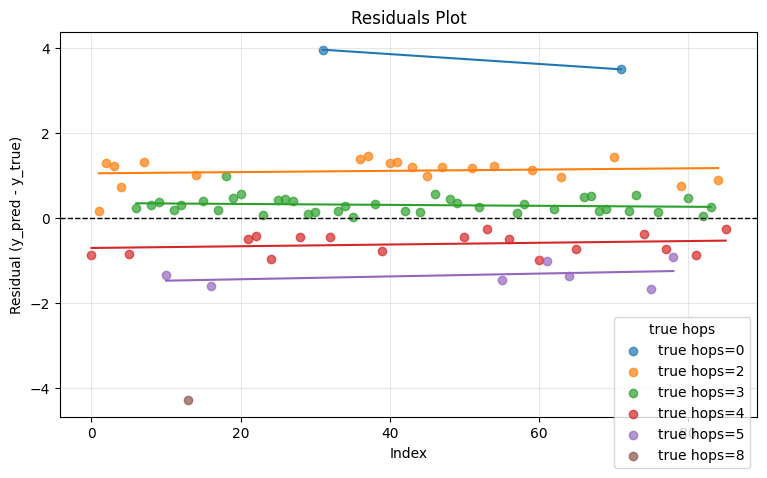

In [79]:
plot_residuals(y_val, y_val_pred, groupby=True)

In [74]:
df = pd.DataFrame({
    'y_val': y_val,
    'residual': y_val_pred - y_val
})

df.groupby('y_val')['residual'].mean()

y_val
0    3.731017
2    1.110738
3    0.309530
4   -0.609966
5   -1.334162
8   -4.271709
Name: residual, dtype: float64

In [75]:
bias = df.groupby('y_val')['residual'].mean()
y_val_pred_corrected = y_val_pred - y_val.map(bias)


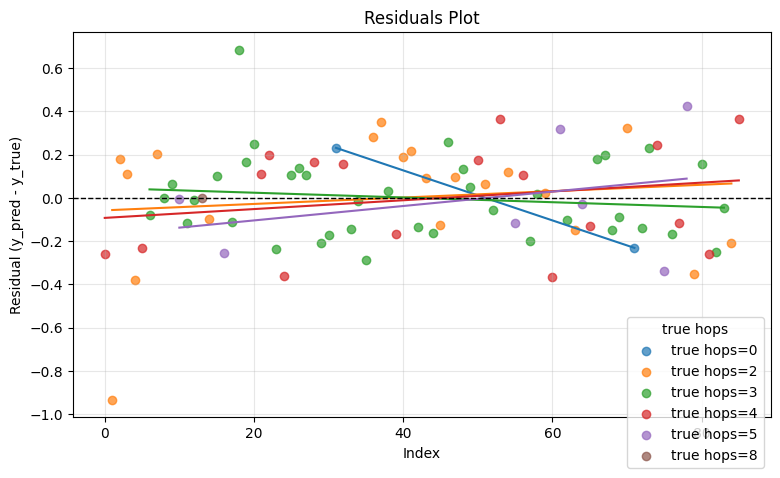

In [80]:
plot_residuals(y_val, y_val_pred_corrected, groupby=True)

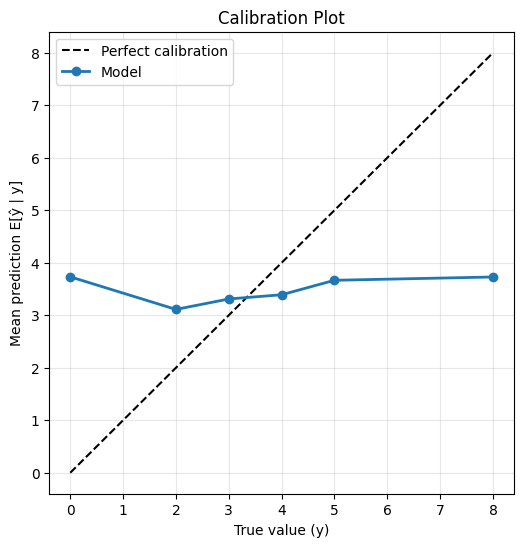

In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def calibration_plot(y_true, y_pred, figsize=(6, 6)):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    df = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred
    })

    calib = (
        df.groupby('y_true')['y_pred']
          .agg(['mean', 'count'])
          .reset_index()
    )

    plt.figure(figsize=figsize)

    # perfect calibration line
    plt.plot(
        calib['y_true'],
        calib['y_true'],
        'k--',
        label='Perfect calibration'
    )

    # model calibration
    plt.plot(
        calib['y_true'],
        calib['mean'],
        'o-',
        linewidth=2,
        label='Model'
    )

    plt.xlabel('True value (y)')
    plt.ylabel('Mean prediction E[ŷ | y]')
    plt.title('Calibration Plot')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# usage
calibration_plot(y_val, y_val_pred)


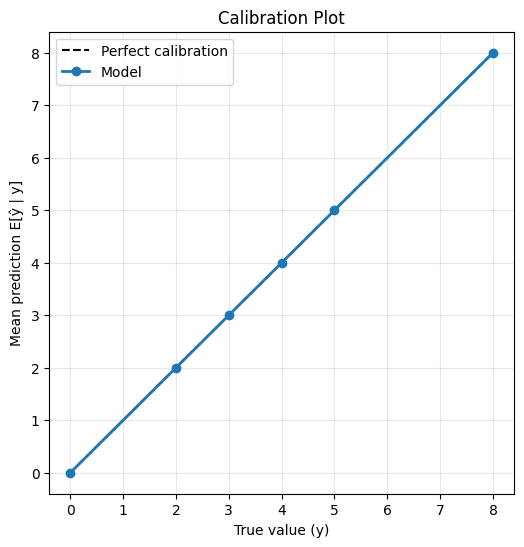

In [82]:
calibration_plot(y_val, y_val_pred_corrected)


/tmp/ipykernel_18097/3270656838.py:27: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('bin')


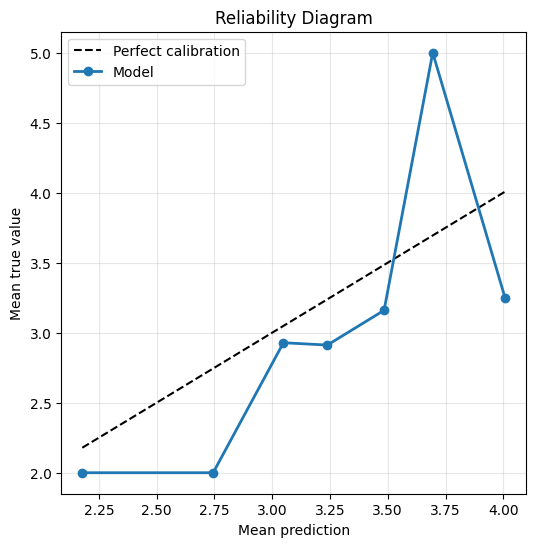

In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def reliability_diagram(
    y_true,
    y_pred,
    n_bins=8,
    figsize=(6, 6)
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    df = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred
    })

    # bin predictions
    df['bin'] = pd.cut(
        df['y_pred'],
        bins=n_bins,
        include_lowest=True
    )

    calib = (
        df.groupby('bin')
          .agg(
              mean_pred=('y_pred', 'mean'),
              mean_true=('y_true', 'mean'),
              count=('y_true', 'count')
          )
          .dropna()
    )

    plt.figure(figsize=figsize)

    # perfect calibration
    plt.plot(
        calib['mean_pred'],
        calib['mean_pred'],
        'k--',
        label='Perfect calibration'
    )

    # model
    plt.plot(
        calib['mean_pred'],
        calib['mean_true'],
        'o-',
        linewidth=2,
        label='Model'
    )

    plt.xlabel('Mean prediction')
    plt.ylabel('Mean true value')
    plt.title('Reliability Diagram')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

    return calib
calib_df = reliability_diagram(y_val, y_val_pred, n_bins=8)

In [84]:
def calibration_error(
    y_true,
    y_pred,
    n_bins=8
):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    df = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred
    })

    df['bin'] = pd.cut(
        df['y_pred'],
        bins=n_bins,
        include_lowest=True
    )

    calib = (
        df.groupby('bin')
          .agg(
              mean_pred=('y_pred', 'mean'),
              mean_true=('y_true', 'mean'),
              count=('y_true', 'count')
          )
          .dropna()
    )

    total = calib['count'].sum()
    abs_error = np.abs(calib['mean_pred'] - calib['mean_true'])

    ece = (calib['count'] / total * abs_error).sum()
    mce = abs_error.max()

    return ece, mce
ece, mce = calibration_error(y_val, y_val_pred, n_bins=8)
print(f"ECE: {ece:.3f}, MCE: {mce:.3f}")

ECE: 0.389, MCE: 1.305


/tmp/ipykernel_18097/2208428880.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('bin')


In [ ]:
def ordinal_bias_correction(y_true, y_pred):
    df = pd.DataFrame({
        'y_true': y_true,
        'y_pred': y_pred
    })

    bias = df.groupby('y_true')['y_pred'].mean() - bias.index
    y_pred_corr = y_pred - y_true.map(bias)

    return y_pred_corr


In [76]:
y_val_pred_corrected

422    3.741667
75     1.067697
177    2.180783
30     2.108504
361    1.621628
         ...   
379    3.741696
57     2.751862
124    2.951824
24     1.790195
17     4.363807
Name: hops, Length: 86, dtype: float64

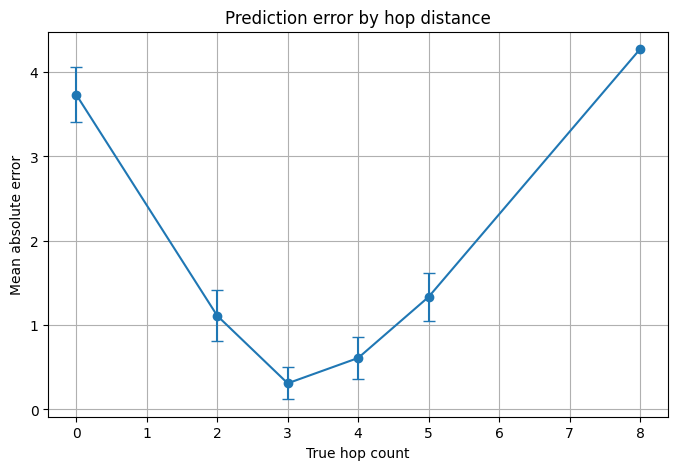

   true_hop  mean_abs_error  std_abs_error  count
0         0        3.731017       0.326746      2
1         2        1.110738       0.302435     20
2         3        0.309530       0.188725     39
3         4        0.609966       0.247233     17
4         5        1.334162       0.281247      7
5         8        4.271709            NaN      1


In [39]:
agg_table = plot_error_by_hop(y_val, y_val_pred)

print(agg_table)


In [85]:
import numpy as np
import plotly.express as px


# thresholds for slider
thresholds = np.round(np.arange(0.0, 1.01, 0.1), 2)
corr = X_explore.corr(method="pearson")  # or spearman
# build frames
frames = []
for t in thresholds:
    corr_masked = corr.where(corr.abs() >= t)

    frames.append(
        dict(
            name=str(t),
            data=[dict(
                type="heatmap",
                z=corr_masked.values,
                x=corr.columns,
                y=corr.index,
                zmin=-1,
                zmax=1
            )]
        )
    )

# base figure
fig = px.imshow(
    corr,
    text_auto=".2f",
    aspect="auto"
)

fig.update_layout(
    title="Feature Correlation Matrix (|corr| threshold)",
    height=max(800, 40 * len(corr)),
    xaxis_tickangle=45,
    sliders=[{
        "steps": [
            {
                "method": "animate",
                "label": f"|corr| ≥ {t}",
                "args": [[str(t)], {"mode": "immediate", "frame": {"duration": 0}}]
            }
            for t in thresholds
        ],
        "currentvalue": {"prefix": "Threshold: "}
    }]
)

fig.update(frames=frames)
fig.show()

In [69]:
X_reduced = X[['cos_sim_src_dst', 'popularity_src', 'popularity_dst','max_cos_dstnbr_src','max_cos_srcnbr_dst']]

In [91]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
X_vif = X[feature_groups['geometry']].replace([np.inf, -np.inf], np.nan).dropna()
vif_df = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df

/home/jonnym/.local/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning:

divide by zero encountered in scalar divide



,feature,VIF
0,cos_sim_src_dst,inf
2,dot_src_dst,inf
1,l2_dist_src_dst,1379.716061
3,abs_diff_mean,933.623678
4,abs_diff_max,84.694743


In [71]:
X_explore.shape

(300, 15)

In [75]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, Ridge, LinearRegression
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(
    X_explore, y, test_size=0.3, random_state=42
)


In [78]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

In [79]:
lasso = Lasso(alpha=0.1)
ridge = Ridge(alpha=1.0)

lasso.fit(X_train_imp, y_train)
ridge.fit(X_train_imp, y_train)


,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [80]:
def gaussian_loglik(y, y_hat, sigma2):
    n = len(y)
    return -0.5 * n * (np.log(2 * np.pi * sigma2) + 1)


In [81]:
def extract_ic(model, X, y, k_penalty):
    n = len(y)
    y_hat = model.predict(X)
    rss = np.sum((y - y_hat) ** 2)

    sigma2 = rss / n
    loglik = gaussian_loglik(y, y_hat, sigma2)

    # effective parameters
    k = np.sum(model.coef_ != 0) + 1  # + intercept

    ic = -2 * loglik + k_penalty * k
    return ic


In [82]:
aic_lasso = extract_ic(lasso, X_train_imp, y_train, k_penalty=2)
aic_ridge = extract_ic(ridge, X_train_imp, y_train, k_penalty=2)

bic_lasso = extract_ic(lasso, X_train_imp, y_train, k_penalty=np.log(len(y_train)))
bic_ridge = extract_ic(ridge, X_train_imp, y_train, k_penalty=np.log(len(y_train)))


In [84]:
ols = LinearRegression().fit(X_train_imp, y_train)
sigma2_hat = np.sum((y_train - ols.predict(X_train_imp))**2) / (
    len(y_train) - X_train_imp.shape[1] - 1
)


In [85]:
def mallows_cp(model, X, y, sigma2):
    n = len(y)
    rss = np.sum((y - model.predict(X))**2)
    k = np.sum(model.coef_ != 0) + 1
    return rss / sigma2 - (n - 2 * k)


In [86]:
cp_lasso = mallows_cp(lasso, X_train_imp, y_train, sigma2_hat)
cp_ridge = mallows_cp(ridge, X_train_imp, y_train, sigma2_hat)


In [87]:
from sklearn.metrics import mean_squared_error

mse_lasso = mean_squared_error(y_test, lasso.predict(X_test_imp))
mse_ridge = mean_squared_error(y_test, ridge.predict(X_test_imp))


In [88]:
print("=== Information Criteria (Training Set) ===\n")

print(f"Lasso AIC : {aic_lasso:.3f}")
print(f"Ridge AIC : {aic_ridge:.3f}\n")

print(f"Lasso BIC : {bic_lasso:.3f}")
print(f"Ridge BIC : {bic_ridge:.3f}\n")

print(f"Lasso Cp  : {cp_lasso:.3f}")
print(f"Ridge Cp  : {cp_ridge:.3f}\n")

print("=== Test Set Performance ===\n")

print(f"Lasso Test MSE : {mse_lasso:.4f}")
print(f"Ridge Test MSE : {mse_ridge:.4f}")


=== Information Criteria (Training Set) ===

Lasso AIC : 596.837
Ridge AIC : 611.802

Lasso BIC : 606.878
Ridge BIC : 665.355

Lasso Cp  : 18.199
Ridge Cp  : 32.824

=== Test Set Performance ===

Lasso Test MSE : 0.9567
Ridge Test MSE : 0.9546


In [89]:
print("Model    AIC        BIC        Cp        Test MSE")
print("--------------------------------------------------")
print(f"Lasso  {aic_lasso:8.2f}  {bic_lasso:8.2f}  {cp_lasso:8.2f}  {mse_lasso:8.4f}")
print(f"Ridge  {aic_ridge:8.2f}  {bic_ridge:8.2f}  {cp_ridge:8.2f}  {mse_ridge:8.4f}")


Model    AIC        BIC        Cp        Test MSE
--------------------------------------------------
Lasso    596.84    606.88     18.20    0.9567
Ridge    611.80    665.36     32.82    0.9546


In [90]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector
from sklearn.linear_model import LinearRegression


In [97]:
X_train_imp.shape

(210, 15)

In [113]:
n_features = X_train_imp.shape[1]

efs = ExhaustiveFeatureSelector(
    Lasso(alpha=1),
    min_features=1,
    max_features=n_features,   # == 15
    scoring="neg_mean_squared_error",
    cv=0
)

efs.fit(X_train_imp, y_train)

Features: 32767/32767

,estimator,Lasso(alpha=1)
,min_features,1
,max_features,15
,print_progress,True
,scoring,'neg_mean_squared_error'
,cv,0
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None
,feature_groups,"[[0], [1], ...]"


In [100]:
efs.subsets_

{0: {'feature_idx': (0,),
  'cv_scores': array([-1.08083502]),
  'avg_score': -1.0808350212710995,
  'feature_names': ('0',)},
 1: {'feature_idx': (1,),
  'cv_scores': array([-1.08154171]),
  'avg_score': -1.0815417116870503,
  'feature_names': ('1',)},
 2: {'feature_idx': (2,),
  'cv_scores': array([-1.08083502]),
  'avg_score': -1.0808350212710995,
  'feature_names': ('2',)},
 3: {'feature_idx': (3,),
  'cv_scores': array([-1.08134145]),
  'avg_score': -1.0813414484894226,
  'feature_names': ('3',)},
 4: {'feature_idx': (4,),
  'cv_scores': array([-1.0810814]),
  'avg_score': -1.0810813996727804,
  'feature_names': ('4',)},
 5: {'feature_idx': (5,),
  'cv_scores': array([-0.98695895]),
  'avg_score': -0.9869589497351177,
  'feature_names': ('5',)},
 6: {'feature_idx': (6,),
  'cv_scores': array([-1.03914688]),
  'avg_score': -1.0391468816948153,
  'feature_names': ('6',)},
 7: {'feature_idx': (7,),
  'cv_scores': array([-1.08083323]),
  'avg_score': -1.0808332325784662,
  'feature_na

In [114]:
import numpy as np

n = len(y_train)
results = []

for k, v in efs.subsets_.items():
    mse = v["avg_score"] * -1
    rss = mse * n
    p = len(v["feature_idx"]) + 1  # + intercept

    aic = n * np.log(rss / n) + 2 * p
    bic = n * np.log(rss / n) + np.log(n) * p

    results.append((p - 1, v["feature_idx"], aic, bic))


In [116]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

# ---- feature names (from original DataFrame) ----
feature_names = X_train.columns.tolist()

# ---- helper: index -> feature names ----
def idx_to_features(idx):
    return [feature_names[i] for i in idx]

# ---- build summary table (like summary(regsubsets)) ----
summary = []

for model_size, idx, aic, bic in results:
    summary.append({
        "model_size": model_size,
        "features": idx_to_features(idx),
        "AIC": aic,
        "BIC": bic
    })

df_summary = pd.DataFrame(summary).sort_values("BIC").reset_index(drop=True)

# ---- best model by BIC ----
best = df_summary.iloc[0]

print("=== Best Subset Model (by BIC) ===\n")
print(f"Model size : {best.model_size}")
print(f"Features   : {best.features}")
print(f"AIC        : {best.AIC:.3f}")
print(f"BIC        : {best.BIC:.3f}\n")

# ---- optional: refit best model & test MSE ----
best_idx = [feature_names.index(f) for f in best.features]

X_train_best = X_train_imp[:, best_idx]
X_test_best  = X_test_imp[:, best_idx]

model = LinearRegression().fit(X_train_best, y_train)
test_mse = np.mean((y_test - model.predict(X_test_best))**2)

print(f"Test MSE   : {test_mse:.4f}")

# ---- display top models ----
display(df_summary.head(18))


=== Best Subset Model (by BIC) ===

Model size : 1
Features   : ['mean_cos_srcnbr_dst']
AIC        : 20.461
BIC        : 27.156

Test MSE   : 1.0464


,model_size,features,AIC,BIC
0,1,[mean_cos_srcnbr_dst],20.461428,27.155644
1,1,[mean_topk_cos_srcnbr_dst],20.461428,27.155644
2,1,[num_src_neighbors],20.461428,27.155644
3,1,[max_cos_dstnbr_src],20.461428,27.155644
4,1,[mean_cos_dstnbr_src],20.461428,27.155644
5,1,[mean_topk_cos_dstnbr_src],20.461428,27.155644
6,1,[num_dst_neighbors],20.461428,27.155644
7,1,[cos_sim_src_dst],20.461428,27.155644
8,1,[l2_dist_src_dst],20.461428,27.155644
9,1,[dot_src_dst],20.461428,27.155644


In [104]:
X_train_imp[5],X_train_imp[6]

(array([0.89628336, 0.45544843, 0.89628336, 0.06616778, 0.15975725,
        7.383     , 5.579     , 0.93170666, 0.89756282, 0.92886627,
        5.        , 0.91938338, 0.80824621, 0.80824621, 3.        ]),
 array([0.63381886, 0.85578168, 0.63381886, 0.12992637, 0.34706678,
        5.7288    , 6.1292    , 0.90527962, 0.79297465, 0.79297465,
        3.        , 0.63452196, 0.6155935 , 0.6155935 , 2.        ]))

In [117]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=10).fit(X_train_imp, y_train)

lasso_features = np.where(lasso.coef_ != 0)[0]

In [119]:
lasso.coef_

array([ 0.        , -0.        ,  0.        , -0.        , -0.        ,
       -0.21626607, -0.12201491,  0.        ,  0.        ,  0.        ,
       -0.        ,  0.        ,  0.        ,  0.        ,  0.        ])

In [ ]:
### Pipeline into the model

# Model

In [ ]:
# Validation metrics


### Group 2 — One-Hop Reachability Proxies (Critical)

**Purpose:**  
*Can `src` reach `dst` in one or two steps?*

Let:
- \( N(src) \) = collaborators of `src`
- \( N(dst) \) = collaborators of `dst`

Using neighbor embeddings:

**Src → Dst**
- `max_cos(src_neighbors, dst)`
- `mean_top3_cos(src_neighbors, dst)`
- `mean_cos(src_neighbors, dst)`

**Dst → Src**
- `max_cos(dst_neighbors, src)`
- `mean_top3_cos(dst_neighbors, src)`
- `mean_cos(dst_neighbors, src)`

These features act as **direct approximations of BFS depth 1–2**.

---



### Group 3 — Two-Hop Structural Features (Cheap + Powerful)

**Purpose:**  
*Do the artists share common intermediates?*

Pure graph features (no embeddings):

- `shared_neighbors = |N(src) ∩ N(dst)|`
- `jaccard_neighbors`
- `adamic_adar`
- `preferential_attachment = deg(src) × deg(dst)`

These capture **two-hop shortcuts** that embedding geometry often blurs.

---



### Group 4 — Connectivity Priors (Degree Effects)

**Purpose:**  
*How likely is each node to act as a hub?*

- `log_deg_src`
- `log_deg_dst`
- `deg_ratio = deg(src) / (deg(dst) + 1)`
- `min_deg`, `max_deg`

These features help the model learn:
- hubs → shorter expected distances  
- hub-to-hub ≠ leaf-to-leaf behavior

---



### Group 5 — Track-Level Aggregates (Optional but Strong)

**Purpose:**  
*Do their collaborative contexts overlap?*

From track-level collaborators:

- `mean_cos(src_track_collabs, dst_track_collabs)`
- `max_cos(src_track_collabs, dst)`
- `max_cos(dst_track_collabs, src)`
- `shared_track_collaborators_count`

These help distinguish:
- same-scene artists  
- distant or cross-genre collaborations

---



### Group 6 — Temporal / Metadata Priors (Optional)

Included only if inexpensive to compute:

- `active_year_overlap`
- `career_gap = |median_year_src − median_year_dst|`
- `num_tracks_src`, `num_tracks_dst`

These act as **weak priors**, not primary signals.

---



## Summary

This feature design explicitly mirrors BFS expansion:

- **Global geometry** → coarse proximity  
- **Neighbor aggregation** → 1–2 hop reachability  
- **Graph structure** → shortcut detection  
- **Degree priors** → hub effects  

The model therefore learns an **approximate graph-distance heuristic**, not just generic similarity.
